# Tilt Census

Counts and distributions of tilt distance and direction by eddy type and region.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)

region_group_map = {"S1": "Shelf", "S2": "Shelf", "U1": "Upstream", "U2": "Upstream", "D1": "Downstream", "D2": "Downstream"}
df_eddies["RegionGroup"] = df_eddies.Region.map(region_group_map)
df_eddies.head()


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region,RegionGroup
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,47.992205,1.434563,74.597458,38,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,U2,Upstream
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,50.858737,1.417135,76.449111,38,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,U2,Upstream
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,53.725269,1.413542,78.300764,38,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,U2,Upstream
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,56.591801,1.411879,69.625773,38,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976810,184.917206,U2,Upstream
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,57.471319,1.597888,72.613632,38,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.067059,181.174121,U2,Upstream


In [2]:
for cyc in ['AE', 'CE']:

    df = df_eddies[df_eddies.Cyc == cyc]

    n_eddies = df.Eddy.nunique()
    n_eddy_days = len(df)
    n_tilt = df.TiltDis.notna().sum()

    print(f'No. {cyc}s               : {n_eddies:,}')
    print(f'No. {cyc} eddy-days     : {n_eddy_days:,}')
    print(f'No. {cyc} tilt estimates: {n_tilt:,}')
    print(f'Tilt success rate       : {100*n_tilt/(n_eddy_days-6*n_eddies):.1f}%')
    print()

n_eddies = df_eddies.Eddy.nunique()
n_eddy_days = len(df_eddies)
n_tilt = df_eddies.TiltDis.notna().sum()

print(f'Total eddies        : {n_eddies:,}')
print(f'Total eddy-days     : {n_eddy_days:,}')
print(f'Total tilt estimates: {n_tilt:,}')
print(f'Tilt success rate   : {100*n_tilt/(n_eddy_days-6*n_eddies):.1f}%')

No. AEs               : 1,414
No. AE eddy-days     : 63,831
No. AE tilt estimates: 53,193
Tilt success rate       : 96.1%

No. CEs               : 1,515
No. CE eddy-days     : 61,395
No. CE tilt estimates: 51,266
Tilt success rate       : 98.0%

Total eddies        : 2,929
Total eddy-days     : 125,226
Total tilt estimates: 104,459
Tilt success rate   : 97.0%


In [3]:
census = (
    df_eddies
    .groupby(["Cyc", "RegionGroup"], dropna=False)
    .agg(eddy_days=("Eddy", "size"), unique_eddies=("Eddy", "nunique"), tilt_days=("TiltDis", "count"), median_tilt=("TiltDis", "median"), mean_dir=("TiltDir", tilt.circular_mean_deg_true_north))
    .reset_index()
)
census


,Cyc,RegionGroup,eddy_days,unique_eddies,tilt_days,median_tilt,mean_dir
0,AE,Downstream,35659,859,30278,15.838327,NaN
1,AE,Shelf,8985,404,7196,17.303306,NaN
2,AE,Upstream,19187,574,15719,29.884091,NaN
3,CE,Downstream,26096,779,21870,12.956538,NaN
4,CE,Shelf,13248,542,10771,11.894466,NaN
5,CE,Upstream,22051,597,18625,23.607385,NaN


In [4]:
def eddy_summary(g):
    if g.empty:
        return None

    tdir = g.TiltDir.dropna()

    return pd.Series({
        'Cyc': g.Cyc.iloc[0],
        'ave_TDis': g.TiltDis.mean(),
        'min_TDis': g.TiltDis.min(),
        'max_TDis': g.TiltDis.max(),
        'ave_TDir': (
            tilt.circular_mean_deg_true_north(tdir)
            if len(tdir) > 0 else np.nan
        )
    })


df_eddy_data = (
    df_eddies
    .groupby('Eddy', group_keys=False)
    # .filter(lambda g: g.TiltDis.notna().sum() >= 30)
    # .groupby('Eddy')
    .apply(eddy_summary, include_groups=False)
    .reset_index()
    .dropna()
)


In [5]:
# fig, axs = plt.subplots(3, 1, figsize=(9, 8), constrained_layout=True)
# metrics = [("TiltDis", "Tilt distance (km)"),
#            ("Age", "Age (days)"),
#            ("Rc", "Radius (km)")]
# for ax, (col, xlabel) in zip(axs, metrics):
#     ae = df_eddies.loc[df_eddies.Cyc == "AE", col].dropna()
#     ce = df_eddies.loc[df_eddies.Cyc == "CE", col].dropna()
#     bins = tilt.shared_bins(ae, ce)
#     tilt.mirrored_hist(ax, ae, ce, bins, xlabel)
# axs[0].legend(frameon=False)
# plt.show()


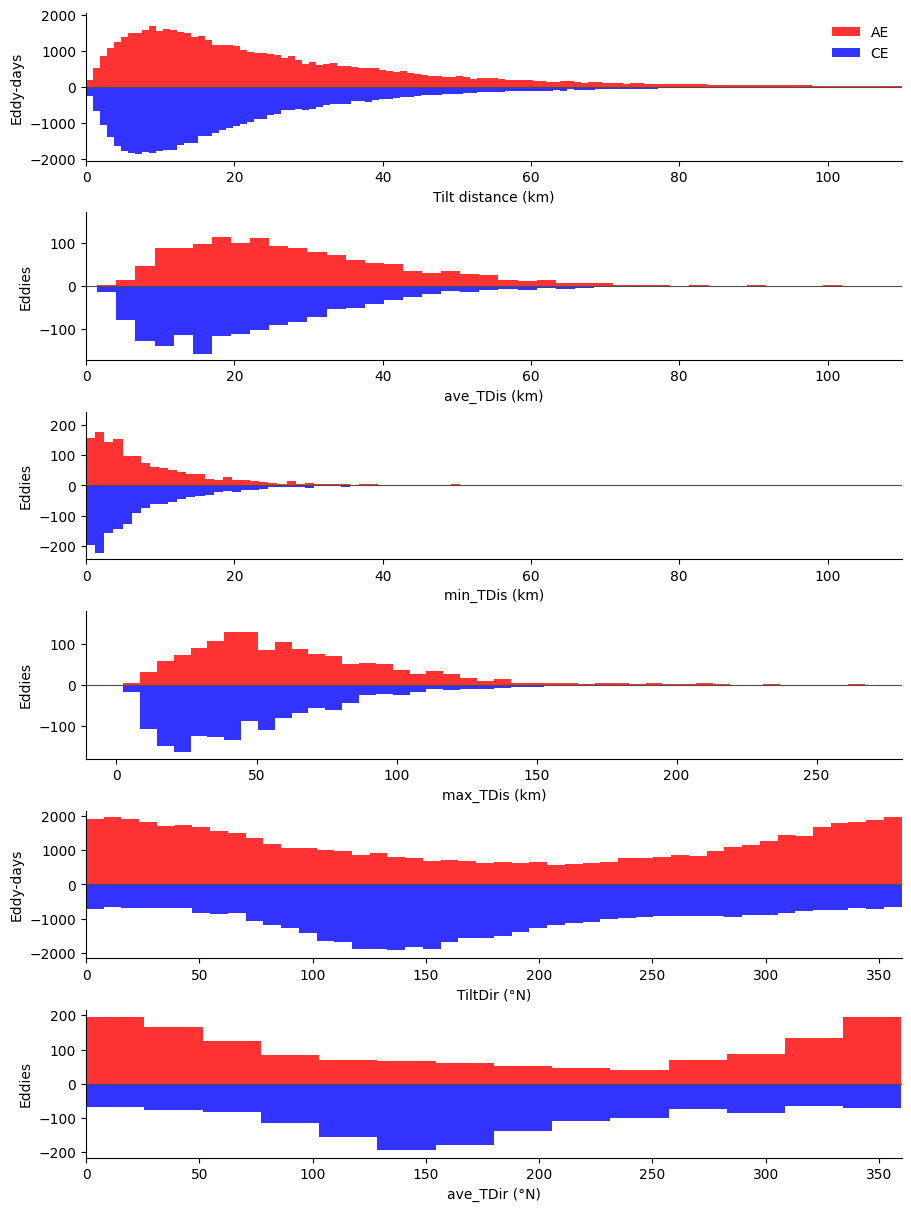

In [8]:
fig, axs = plt.subplots(6, 1, figsize=(9, 12), constrained_layout=True)
metrics = [("TiltDis", "Tilt distance (km)", (0,110)),
           ("ave_TDis", "ave_TDis (km)", (0,110)),
           ("min_TDis", "min_TDis (km)", (0,110)),
           ("max_TDis", "max_TDis (km)", None),
           ("TiltDir", "TiltDir (°N)", (0,360)),
           ("ave_TDir", "ave_TDir (°N)", (0,360))]

for ax, (col, xlabel, xlim) in zip(axs, metrics):
    if col in ['ave_TDis', 'min_TDis', 'max_TDis', 'ave_TDir']:
        df = df_eddy_data.copy()
        ylabel = 'Eddies'
    else:
        df = df_eddies.copy()
        ylabel = 'Eddy-days'
    ae = df.loc[df.Cyc == "AE", col].dropna()
    ce = df.loc[df.Cyc == "CE", col].dropna()
    bins = tilt.shared_bins(ae, ce)
    
    tilt.mirrored_hist(ax, ae, ce, bins, xlabel, xlim=xlim, ylabel=ylabel)
axs[0].legend(frameon=False)
plt.show()


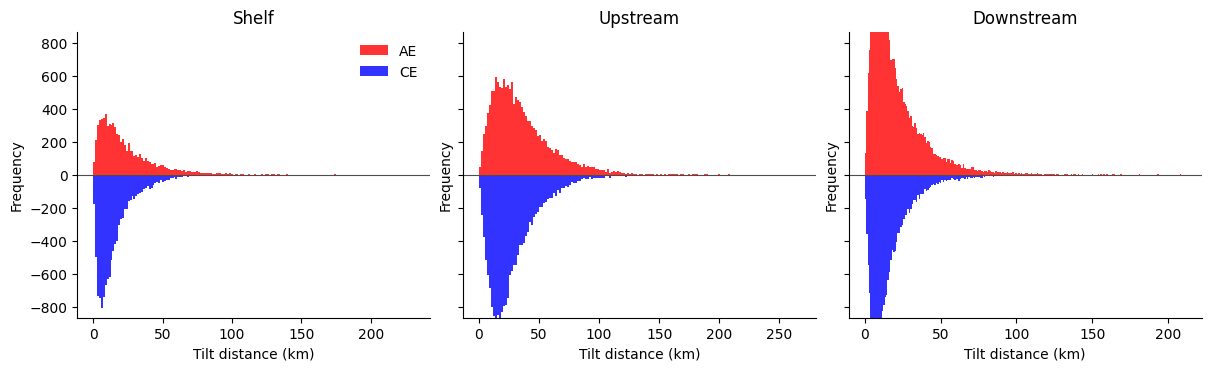

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True, constrained_layout=True)
for ax, region in zip(axs, ["Shelf", "Upstream", "Downstream"]):
    subset = df_eddies.loc[df_eddies.RegionGroup == region]
    ae = subset.loc[subset.Cyc == "AE", "TiltDis"].dropna()
    ce = subset.loc[subset.Cyc == "CE", "TiltDis"].dropna()
    bins = tilt.shared_bins(ae, ce)
    tilt.mirrored_hist(ax, ae, ce, bins, "Tilt distance (km)")
    ax.set_title(region)
axs[0].legend(frameon=False)
plt.show()
